In [1]:
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from working_data import clean_cols, add_timing, alt_label_df as label_df, normalize_by_window, split_multiresolution_chunks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from model_builder_trans import recommended_trading_loss as combined_loss
from multi_instrument_data_generator import InstrumentConfig, MultiInstrumentDatasetConfig, create_multi_instrument_dataset
from transformer_builder import LearnablePositionalEncoding, StochasticGatedTransformerBlock, WarmupCosineDecay
from tensorflow.keras.layers import Input, Conv1D,  Dense, concatenate, Dropout, Layer, GlobalAveragePooling1D, GlobalMaxPooling1D, LayerNormalization, Add
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding

2025-06-19 10:50:16.488240: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-19 10:50:16.542305: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-19 10:50:17.300320: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-06-19 10:50:18.586330: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-19 10:50:18.646165: 

In [2]:
NORMALIZING_WINDOW_SIZE = 6*24
LABELING_WINDOW_SIZE = 18
POSITIVE_SLOPE = 0.3
NEGATIVE_SLOPE = 0.7
STARTING_HOUR = 8
ENDING_HOUR = 17
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 6
BATCH_SIZE = 64
NUM_TOKENS = 64
OTHER_TOKENS = 64
LOOKBACK_WINDOW = NUM_TOKENS + 1
D_MODEL = 512
FF_DIM = D_MODEL * 4
NUM_HEADS = D_MODEL//24
DRAWDOWN = 0.5
LABEL_LOOKBACK = 512

In [3]:
working_path = "split_data"

In [4]:
instruments = [
    'GBPUSD',
    'EURUSD'
]

# for instrument in instruments:
#     df = pd.read_csv(f"super_data/{instrument}/five_minutes.csv")
#     df = clean_cols(df)
#     df = add_timing(df)
#     df = normalize_by_window(
#         df, 
#         window_size=NORMALIZING_WINDOW_SIZE, 
#         low_col='low',
#         high_col='high',
#         normalizing_cols=[
#             'open',
#             'high',
#             'low',
#             'close'
#         ],
#         label_cols=['open', 'close'])
#     print(f"Labeling {instrument}")
#     df = label_df(df, window_size=LABELING_WINDOW_SIZE, 
#                   mean_multiplier=LABEL_MEAN_MULTIPLIER, 
#                   cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER, 
#                   positive_slope=POSITIVE_SLOPE, 
#                   negative_slope=NEGATIVE_SLOPE,
#                   starting_hour=STARTING_HOUR,
#                   ending_hour=ENDING_HOUR,
#                   drawdown=DRAWDOWN,
#                   lookback_window=LABEL_LOOKBACK)
    
#     hour_df = pd.read_csv(f"super_data/{instrument}/hours.csv")
#     hour_df = clean_cols(hour_df)
#     hour_df = normalize_by_window(
#         hour_df, 
#         window_size=NORMALIZING_WINDOW_SIZE, 
#         low_col='low',
#         high_col='high',
#         normalizing_cols=[
#             'open',
#             'high',
#             'low',
#             'close'
#         ],
#         label_cols=['open', 'close'])
    
#     os.makedirs(f"{working_path}/{instrument}", exist_ok=True)

#     hour_df.to_csv(f"{working_path}/{instrument}/hour.csv", index=False)
#     split_multiresolution_chunks(df_5min=df,
#                                 df_hour=hour_df,
#                                 dump_path=f"{working_path}/{instrument}",
#                                 chunk_size=60000,
#                                 hour_lookback=OTHER_TOKENS,
#                                 lookback=NUM_TOKENS,
#                                 cols=[
#                                     'time',
#                                     'position_in_hour',
#                                     'hour_of_day',
#                                     'open',
#                                     'high',
#                                     'low',
#                                     'close',
#                                     'open_normalized',
#                                     'high_normalized',
#                                     'low_normalized',
#                                     'close_normalized',
#                                     'include',
#                                     'target'
#                                 ])



In [5]:
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()

In [6]:
feature_cols = [
    'open_normalized',
    'high_normalized',
    'low_normalized',
    'close_normalized'
]


train_instrument_configs = []
val_instrument_configs = []
test_instrument_configs = []

for instrument in instruments:
    train_instrument_configs.append(
        InstrumentConfig(
            name=instrument,
            hourly_data_path=f"{working_path}/{instrument}/hour.csv",
            chunked_data_dir=f"{working_path}/{instrument}/training"
        )
    )
    val_instrument_configs.append(
        InstrumentConfig(
            name=instrument,
            hourly_data_path=f"{working_path}/{instrument}/hour.csv",
            chunked_data_dir=f"{working_path}/{instrument}/validation"
        )
    )
    test_instrument_configs.append(
        InstrumentConfig(
            name=instrument,
            hourly_data_path=f"{working_path}/{instrument}/hour.csv",
            chunked_data_dir=f"{working_path}/{instrument}/testing"
        )
    )

train_config = MultiInstrumentDatasetConfig(
    instruments=train_instrument_configs,
    main_lookback_tokens=NUM_TOKENS,
    hourly_lookback_tokens=OTHER_TOKENS,
    lookback_window=LOOKBACK_WINDOW,
    batch_size=BATCH_SIZE,
    apply_smote=True,
    shuffle_data=True,
    feature_columns=feature_cols,
    max_chunks_per_instrument=100
)

val_config = MultiInstrumentDatasetConfig(
    instruments=val_instrument_configs,
    main_lookback_tokens=NUM_TOKENS,
    hourly_lookback_tokens=OTHER_TOKENS,
    lookback_window=LOOKBACK_WINDOW,
    batch_size=BATCH_SIZE,
    apply_smote=False,
    shuffle_data=False,
    feature_columns=feature_cols,
    max_chunks_per_instrument=25
)

test_config = MultiInstrumentDatasetConfig(
    instruments=test_instrument_configs,
    main_lookback_tokens=NUM_TOKENS,
    hourly_lookback_tokens=OTHER_TOKENS,
    lookback_window=LOOKBACK_WINDOW,
    batch_size=BATCH_SIZE,
    apply_smote=False,
    shuffle_data=False,
    feature_columns=feature_cols,
    max_chunks_per_instrument=25
)


train_dataset, train_rows = create_multi_instrument_dataset(
    config=train_config,
    repeat_dataset=True
)
val_dataset, val_rows = create_multi_instrument_dataset(
    config=val_config,
    repeat_dataset=True
)
test_dataset, test_rows = create_multi_instrument_dataset(
    config=test_config,
    repeat_dataset=True
)

train_steps = train_rows//BATCH_SIZE
val_steps = val_rows//BATCH_SIZE
test_steps = test_rows//BATCH_SIZE

2025-06-19 10:50:19,123 - INFO - Discovered 30 chunk files for GBPUSD
2025-06-19 10:50:19,123 - INFO - Loading hourly data for GBPUSD...
2025-06-19 10:50:19,172 - INFO - Loaded hourly data for GBPUSD: 151739 rows
2025-06-19 10:50:19,178 - INFO - Applied time threshold for GBPUSD: 979279200
2025-06-19 10:50:19,179 - INFO - Building indices for GBPUSD...
2025-06-19 10:50:24,173 - INFO - Built indices for GBPUSD: 26017 positive, 450729 negative samples
2025-06-19 10:50:24,175 - INFO - Discovered 31 chunk files for EURUSD
2025-06-19 10:50:24,175 - INFO - Loading hourly data for EURUSD...
2025-06-19 10:50:24,208 - INFO - Loaded hourly data for EURUSD: 151711 rows
2025-06-19 10:50:24,211 - INFO - Applied time threshold for EURUSD: 979282800
2025-06-19 10:50:24,212 - INFO - Building indices for EURUSD...
2025-06-19 10:50:29,275 - INFO - Built indices for EURUSD: 25763 positive, 451155 negative samples
2025-06-19 10:50:29,276 - INFO - Building global indices across all instruments...
2025-06-1

In [7]:
def create_model(training=True):
    # Main (5-minute) data input
    input_shape = (NUM_TOKENS, len(feature_cols))
    input_layer = Input(shape=input_shape, name='minute_input')
    
    # Hourly data input
    other_input_shape = (OTHER_TOKENS, len(feature_cols))
    other_input_layer = Input(shape=other_input_shape, name='hourly_input')
    
    # Custom layer for adding type embeddings
    class AddTypeEmbedding(Layer):
        def __init__(self, type_id, embed_dim=16, **kwargs):
            super().__init__(**kwargs)
            self.type_id = type_id
            self.embed_dim = embed_dim
            self.embedding_layer = None
            
        def build(self, input_shape):
            self.embedding_layer = Embedding(input_dim=2, output_dim=self.embed_dim, name=f'{self.name}_embed')
            super().build(input_shape)
            
        def call(self, inputs):
            batch_size = tf.shape(inputs)[0]
            seq_len = tf.shape(inputs)[1]
            type_ids = tf.fill((batch_size, seq_len), self.type_id)
            type_embed = self.embedding_layer(type_ids)
            return tf.concat([inputs, type_embed], axis=-1)
            
        def get_config(self):
            config = super().get_config()
            config.update({
                "type_id": self.type_id,
                "embed_dim": self.embed_dim
            })
            return config
    
    # Improved CNN block function
    def cnn_feature_extractor(inputs, name_prefix, max_filter_output=D_MODEL-16):
        # Multi-scale feature extraction
        x = Conv1D(filters=max_filter_output//2, kernel_size=3, activation='relu', padding="same", name=f'{name_prefix}_conv1')(inputs)      
        x = Conv1D(filters=max_filter_output, kernel_size=5, activation='relu', padding="same", name=f'{name_prefix}_conv3')(x)
   
        return x
    
    # Process 5-minute data branch
    x = cnn_feature_extractor(input_layer, '5min', D_MODEL-16)
    x = Dense(D_MODEL - 16, name='5min_projection')(x)  # Reserve 16 dims for type embedding
    x = LearnablePositionalEncoding(maxlen=NUM_TOKENS, d_model=D_MODEL - 16)(x)
    
    # Add type embedding for 5-minute data (type 0)
    x = AddTypeEmbedding(type_id=0, embed_dim=16, name='5min_type_embed')(x)

    # Process hourly data branch
    h = cnn_feature_extractor(other_input_layer, 'hourly', D_MODEL-16)
    h = Dense(D_MODEL - 16, name='hourly_projection')(h)  # Reserve 16 dims for type embedding
    h = LearnablePositionalEncoding(maxlen=OTHER_TOKENS, d_model=D_MODEL - 16)(h)
    
    # Add type embedding for hourly data (type 1)
    h = AddTypeEmbedding(type_id=1, embed_dim=16, name='hourly_type_embed')(h)

    x = concatenate([h, x], axis=1, name='timeframe_concat')  # Shape: (batch, time_combined, d_model)
    x = Dropout(0.1)(x)

    # Deeper transformer stack with increasing stochastic depth
    stochastic_rates = [0.05, 0.1, 0.15, 0.2]
    for i in range(len(stochastic_rates)):  # or 6 if you expand later
        # Pre-norm the input
        x_norm = LayerNormalization(name=f'ln_pre_{i}')(x)

        # Pass through the transformer block
        x_block_out = StochasticGatedTransformerBlock(
            D_MODEL,
            NUM_HEADS,
            FF_DIM,
            rate=0.1,
            attention_dropout=stochastic_rates[i],
            stochastic_depth_rate=stochastic_rates[i]
        )(x_norm, training=training)

        # Apply dropout after the block
        x_block_out = Dropout(0.05, name=f'post_dropout_{i}')(x_block_out)

        # Residual connection: input + block output
        x = Add(name=f'residual_add_{i}')([x, x_block_out])


    # Global pooling with layer norm
    avg_pool = GlobalAveragePooling1D(name='avg_pool')(x)
    max_pool = GlobalMaxPooling1D(name='max_pool')(x)
    
    # Additional feature: attention-weighted pooling
    class AttentionPooling(Layer):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.attention_dense = Dense(1)  # Remove activation here
            
        def call(self, inputs):
            # inputs shape: (batch_size, seq_len, hidden_dim)
            attention_logits = self.attention_dense(inputs)  # (batch_size, seq_len, 1)
            attention_weights = tf.nn.softmax(attention_logits, axis=1)  # Softmax across sequence
            return tf.reduce_sum(inputs * attention_weights, axis=1)
            
        def get_config(self):
            config = super().get_config()
            return config
    
    attention_pool = AttentionPooling(name='attention_pooling')(x)
    
    combined_features = concatenate([avg_pool, max_pool, attention_pool], name='combined_features')
    combined_features = Dropout(0.2)(combined_features)

    dense_out = Dense(D_MODEL, activation='relu', name='pre_output_dense')(combined_features)
    dense_out = Dropout(0.2)(dense_out)
    
    outputs = Dense(1, activation='sigmoid', name='output')(dense_out)

    # Create model
    model = Model(inputs=[input_layer, other_input_layer], outputs=outputs)
    
    return model

model = create_model(training=True)

lr_schedule = WarmupCosineDecay(initial_lr=5e-5, warmup_steps=300000, decay_steps=900000)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)

# Compile the model
model.compile(
    optimizer=optimizer, 
    loss=combined_loss, 
    metrics=['accuracy', auc, prec])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hourly_input        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_input        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_conv1        │ (None, 64, 248)   │      3,224 │ hourly_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 5min_conv1 (Conv1D) │ (None, 64, 248)   │      3,224 │ minute_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_conv3        │ (None, 64, 496)   │    615,536 │ hourly_conv1[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 5min_conv3 (Conv1D) │ (None, 64, 496)   │    615,536 │ 5min_conv1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_projection   │ (None, 64, 496)   │    246,512 │ hourly_conv3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 5min_projection     │ (None, 64, 496)   │    246,512 │ 5min_conv3[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 64, 496)   │     31,744 │ hourly_projectio… │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 64, 496)   │     31,744 │ 5min_projection[… │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_type_embed   │ (None, 64, 512)   │         32 │ learnable_positi… │
│ (AddTypeEmbedding)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 5min_type_embed     │ (None, 64, 512)   │         32 │ learnable_positi… │
│ (AddTypeEmbedding)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ timeframe_concat    │ (None, 128, 512)  │          0 │ hourly_type_embe… │
│ (Concatenate)       │                   │            │ 5min_type_embed[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 512)  │          0 │ timeframe_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_pre_0            │ (None, 128, 512)  │      1,024 │ dropout[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_gated_t… │ (None, 128, 512)  │  3,661,288 │ ln_pre_0[0][0]    │
│ (StochasticGatedTr… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_dropout_0      │ (None, 128, 512)  │          0 │ stochastic_gated… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_0      │ (None, 128, 512)  │          0 │ dropout[0][0],  

 Total params: 17,231,314 (65.73 MB)

 Trainable params: 17,231,314 (65.73 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=10, # Stops if there's no improvement for 3 epochs
                               mode='min', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_multiresolution_model.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   mode='min', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=50,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/50


I0000 00:00:1750323053.099090    1957 service.cc:145] XLA service 0x7efec402bb80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750323053.099161    1957 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2025-06-19 10:50:53.505045: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1750323053.860127    1957 random_ops.cc:59] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. functional_1/stochastic_gated_transformer_block_1/random_uniform/RandomUniform
2025-06-19 10:50:56.182342: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1750323073.974766    2178 asm_compiler.cc:369] ptxas warning : Registers are

28142/28183 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step - accuracy: 0.5331 - auc: 0.5440 - loss: 0.2829 - precision_1: 0.5480

I0000 00:00:1750328603.300383   16544 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_791', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1750328604.624861   16542 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_679', 28 bytes spill stores, 24 bytes spill loads

I0000 00:00:1750328605.794339   16532 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_105', 164 bytes spill stores, 168 bytes spill loads



28183/28183 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5332 - auc: 0.5441 - loss: 0.2828 - precision_1: 0.5481
Epoch 1: val_loss improved from inf to 0.38038, saving model to best_multiresolution_model.keras
28183/28183 ━━━━━━━━━━━━━━━━━━━━ 5942s 209ms/step - accuracy: 0.5332 - auc: 0.5441 - loss: 0.2828 - precision_1: 0.5481 - val_accuracy: 0.8804 - val_auc: 0.6331 - val_loss: 0.3804 - val_precision_1: 0.1275
Epoch 2/50
28183/28183 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5791 - auc: 0.6437 - loss: 0.1547 - precision_1: 0.7250

I0000 00:00:1750334474.567629   30200 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_80', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1750334475.300616   30213 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_33', 164 bytes spill stores, 168 bytes spill loads




Epoch 2: val_loss did not improve from 0.38038
28183/28183 ━━━━━━━━━━━━━━━━━━━━ 5795s 206ms/step - accuracy: 0.5791 - auc: 0.6437 - loss: 0.1547 - precision_1: 0.7250 - val_accuracy: 0.8770 - val_auc: 0.6851 - val_loss: 0.3889 - val_precision_1: 0.1591
Epoch 3/50
28183/28183 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5923 - auc: 0.6966 - loss: 0.1303 - precision_1: 0.8169
Epoch 3: val_loss improved from 0.38038 to 0.36947, saving model to best_multiresolution_model.keras
28183/28183 ━━━━━━━━━━━━━━━━━━━━ 6133s 218ms/step - accuracy: 0.5923 - auc: 0.6966 - loss: 0.1303 - precision_1: 0.8169 - val_accuracy: 0.9053 - val_auc: 0.7103 - val_loss: 0.3695 - val_precision_1: 0.2045
Epoch 4/50
28183/28183 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.5964 - auc: 0.7177 - loss: 0.1237 - precision_1: 0.8307
Epoch 4: val_loss improved from 0.36947 to 0.34199, saving model to best_multiresolution_model.keras
28183/28183 ━━━━━━━━━━━━━━━━━━━━ 5992s 213ms/step - accuracy: 0.5964 - auc: 0.7177

KeyboardInterrupt: 

In [9]:
model = create_model(training=False)
model.load_weights('best_multiresolution_model.keras')

# Make predictions
predictions = model.predict(test_dataset, steps=test_steps)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)

3131/3131 ━━━━━━━━━━━━━━━━━━━━ 308s 96ms/step


Confusion Matrix:
 [[184954   4261]
 [  9489   1680]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96    189215
           1       0.28      0.15      0.20     11169

    accuracy                           0.93    200384
   macro avg       0.62      0.56      0.58    200384
weighted avg       0.91      0.93      0.92    200384



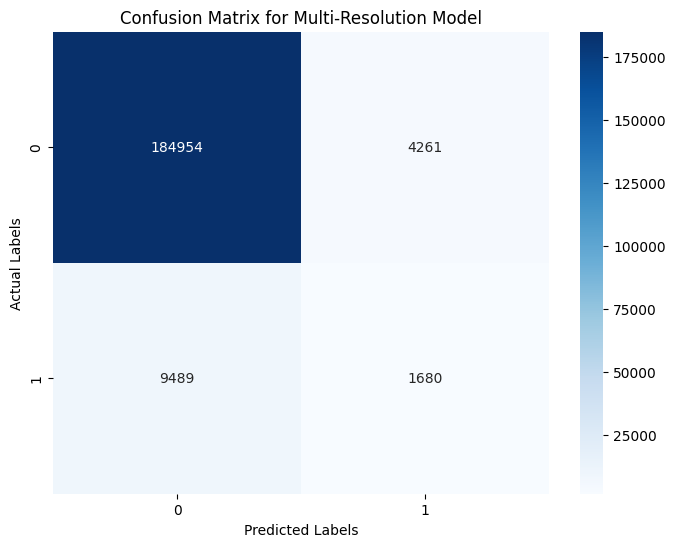

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Collect ground truth labels
y_true = []
for inputs in test_dataset:
    # The test_dataset now returns a tuple of two inputs and one target
    if len(inputs) == 3:  # If unpacked
        minute_input, hourly_input, target = inputs
    else:  # If not unpacked
        target = inputs[-1]
    y_true.extend(target.numpy())
    # Break if we've processed all the steps
    if len(y_true) >= test_steps * BATCH_SIZE:
        break

# Truncate to match the length of predictions
y_true = y_true[:len(predicted_class)]

# Create the confusion matrix
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, predicted_class))

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Multi-Resolution Model')
plt.show()